# EIT Audio Segmentation — v3
## Response-Centric Sequential Mapping

---

### Critical Analysis: Why v1 and v2 Both Failed

**Root cause**: Both previous versions assumed the stimulus is acoustically detectable and used stimulus boundaries to gate response search windows. This was wrong.

**What the data actually shows** (from v2 outputs):
```
VAD segments after 1.2s intra-merge: 31
Inter-segment gaps (first 8):  5.7s, 5.7s, 6.5s, 7.5s, 6.7s, 8.1s, 7.7s ...
Recording duration: 385.37s / 30 pairs = 12.8s per pair
```

**Why the gaps tell us everything**:
- Gaps between detected segments = **5.7–8.1 s** (uniform)
- That 6–8 s of silence = stimulus audio (~2 s, too quiet for VAD) + pre/post pauses
- **All 31 detected segments ARE responses, not stimuli**
- v2 labelled them all as stimuli → excluded them → found only 4 responses

### v3 Design: Response-Only Sequential Mapping
```
Audio
  ↓
VAD (raw segments)
  ↓
Intra-utterance merge  ← handles non-native speaker within-response pauses
  ↓
Duration filter        ← drop noise
  ↓
Gap analysis           ← visualize + confirm only one class of segment exists
  ↓
Smart reduce to N      ← if segments > 30, merge the pair with smallest inter-gap
  ↓                       (always a split response, not adjacent pair responses)
Sequential mapping     ← response[i] → stimulus_id = i+1 (fixed order, known)
  ↓
Export + Diagnostics
```

**No stimulus detection. No stimulus-gated windows. Pure order-based matching.**

---
## Section 1 — Imports

In [1]:
import subprocess, sys
for pkg in ["numpy","scipy","librosa","matplotlib","pandas","soundfile","tqdm","torch","torchaudio","silero-vad"]:
    r = subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"], capture_output=True)
    print(f"{'OK' if r.returncode==0 else 'WARN'} {pkg}")
print("Done.")

OK numpy
OK scipy
OK librosa
OK matplotlib
OK pandas
OK soundfile
OK tqdm
OK torch
OK torchaudio
OK silero-vad
Done.


In [2]:
import numpy as np
import scipy.signal as sig
import librosa, soundfile as sf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, warnings
from pathlib import Path
from tqdm import tqdm
import torch

warnings.filterwarnings('ignore')
print(f"PyTorch {torch.__version__} | {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch 2.10.0 | CPU


---
## Section 2 — Configuration

All tunable parameters. The key new parameters are `INTRA_MERGE_GAP` and `MIN_SEG_DURATION`.

> **Calibration rule of thumb**:
> - `INTRA_MERGE_GAP`: set to slightly *larger* than the longest within-response pause you observe in the gap distribution plot. Should always be much smaller than the inter-pair gap (6–8 s here).
> - `MIN_SEG_DURATION`: set to exclude obvious noise. Look at the shortest detected segments.

In [3]:
# ── Audio files ──────────────────────────────────────────────────────────────
AUDIO_FILES = [
    "/Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai/.cache/038015_1A_preprocessed.wav",
    "/Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai/.cache/038012_2A_preprocessed.wav",
    "/Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai/.cache/038011_1A_preprocessed.wav",
    "/Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai/.cache/038010_2A_preprocessed.wav",
]
CURRENT_FILE_IDX = 1
AUDIO_PATH = AUDIO_FILES[CURRENT_FILE_IDX]

# ── Core ─────────────────────────────────────────────────────────────────────
TARGET_SR   = 16000
NUM_STIMULI = 30          # expected number of responses to recover

# ── VAD ──────────────────────────────────────────────────────────────────────
VAD_THRESHOLD      = 0.4  # slightly lower than default → catch quieter speech
VAD_MIN_SPEECH_MS  = 100  # short to capture all bursts; merging handles length
VAD_MIN_SILENCE_MS = 100  # short; merging is done in a separate explicit step

# ── Intra-utterance merge ─────────────────────────────────────────────────────
# Gap WITHIN one response that VAD incorrectly splits.
# Non-native Spanish speakers pause 0.5–2 s mid-utterance.
# Set LOWER than the observed inter-pair gap (~6 s) to avoid merging across pairs.
INTRA_MERGE_GAP   = 2.0   # seconds  ← start here; raise if responses still split

# ── Duration filter ───────────────────────────────────────────────────────────
MIN_SEG_DURATION  = 0.5   # seconds; drop anything shorter (noise / stimulus leakage)

# ── Smart reduce ─────────────────────────────────────────────────────────────
# When we have > NUM_STIMULI segments, merge the pair with smallest inter-gap.
# Safety: never merge two segments separated by more than this (would be cross-pair).
MAX_MERGE_GAP_FOR_REDUCE = 4.0   # seconds; if smallest gap > this, stop merging

# ── Export ───────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path("eit_output_v3") / Path(AUDIO_PATH).stem
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Stimulus sentences (fixed order — ground truth) ──────────────────────────
STIMULUS_SENTENCES = [
    "Quiero cortarme el pelo",
    "El libro está en la mesa",
    "El carro lo tiene Pedro",
    "El se ducha cada mañana",
    "¿Qué dice usted que va a hacer hoy?",
    "Dudo que sepa manejar muy bien",
    "Las calles de esta ciudad son muy anchas",
    "Puede que llueva mañana todo el día",
    "Las casas son muy bonitas pero caras",
    "Me gustan las películas que acaban bien",
    "El chico con el que yo salgo es español",
    "Después de cenar me fui a dormir tranquilo",
    "Quiero una casa en la que vivan mis animales",
    "A nosotros nos fascinan las fiestas grandiosas",
    "Ella sólo bebe cerveza y no come nada",
    "Me gustaría que el precio de las casas bajara",
    "Cruza a la derecha y después sigue todo recto",
    "Ella ha terminado de pintar su apartamento",
    "Me gustaría que empezara a hacer más calor pronto",
    "El niño al que se le murió el gato está triste",
    "Una amiga mía cuida a los niños de mi vecino",
    "El gato que era negro fue perseguido por el perro",
    "Antes de poder salir él tiene que limpiar su cuarto",
    "La cantidad de personas que fuman ha disminuido",
    "Después de llegar a casa del trabajo tomé la cena",
    "El ladrón al que atrapó la policía era famoso",
    "Le pedí a un amigo que me ayudara con la tarea",
    "El examen no fue tan difícil como me habían dicho",
    "¿Serías tan amable de darme el libro que está en la mesa?",
    "Hay mucha gente que no toma nada para el desayuno",
]
assert len(STIMULUS_SENTENCES) == NUM_STIMULI

print(f"File           : {Path(AUDIO_PATH).name}")
print(f"Output dir     : {OUTPUT_DIR}")
print(f"INTRA_MERGE_GAP: {INTRA_MERGE_GAP}s")
print(f"MIN_SEG_DUR    : {MIN_SEG_DURATION}s")
print(f"MAX_MERGE_REDUCE: {MAX_MERGE_GAP_FOR_REDUCE}s")

File           : 038012_2A_preprocessed.wav
Output dir     : eit_output_v3/038012_2A_preprocessed
INTRA_MERGE_GAP: 2.0s
MIN_SEG_DUR    : 0.5s
MAX_MERGE_REDUCE: 4.0s


---
## Section 3 — Load & Preprocess Audio

In [4]:
def load_audio(file_path, target_sr=TARGET_SR):
    assert os.path.exists(file_path), f"File not found: {file_path}"
    audio, sr = librosa.load(file_path, sr=None, mono=True)
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
        sr = target_sr
    duration = len(audio) / sr
    print(f"Loaded  : {Path(file_path).name}")
    print(f"  SR={sr} Hz | Duration={duration:.2f}s ({duration/60:.2f} min)")
    return audio.astype(np.float32), sr, duration


def preprocess_audio(audio, sr):
    """Peak-normalize → high-pass filter at 80 Hz → re-normalize."""
    def norm(a): p = np.max(np.abs(a)); return (a/p*0.95).astype(np.float32) if p>0 else a
    audio = norm(audio)
    b, a  = sig.butter(4, 80.0/(sr/2.0), btype='high')
    audio = sig.filtfilt(b, a, audio).astype(np.float32)
    audio = norm(audio)
    print(f"Processed: peak={np.max(np.abs(audio)):.4f}  RMS={np.sqrt(np.mean(audio**2)):.4f}")
    return audio


audio_raw, SR, DURATION = load_audio(AUDIO_PATH)
audio      = preprocess_audio(audio_raw, SR)

Loaded  : 038012_2A_preprocessed.wav
  SR=16000 Hz | Duration=387.55s (6.46 min)
Processed: peak=0.9500  RMS=0.0151


---
## Section 4 — Voice Activity Detection

In [5]:
print("Loading Silero VAD...")
vad_model, vad_utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad', model='silero_vad',
    force_reload=False, trust_repo=True
)
get_speech_timestamps = vad_utils[0]
print("OK")

Loading Silero VAD...


Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master


OK


In [6]:
def run_vad(audio, sr,
            threshold=VAD_THRESHOLD,
            min_speech_ms=VAD_MIN_SPEECH_MS,
            min_silence_ms=VAD_MIN_SILENCE_MS):
    """Run Silero VAD. Returns DataFrame[start, end, duration]."""
    assert sr == 16000, "Silero VAD requires 16 kHz"
    ts = get_speech_timestamps(
        torch.from_numpy(audio).float(), vad_model,
        threshold=threshold,
        min_speech_duration_ms=min_speech_ms,
        min_silence_duration_ms=min_silence_ms,
        sampling_rate=sr,
        return_seconds=True
    )
    assert ts, "VAD returned 0 segments — lower VAD_THRESHOLD or check audio."
    df = pd.DataFrame([{'start': t['start'], 'end': t['end'],
                         'duration': t['end']-t['start']} for t in ts])
    return df


vad_raw = run_vad(audio, SR)
print(f"Raw VAD segments  : {len(vad_raw)}")
print(f"Duration range    : {vad_raw['duration'].min():.2f}s – {vad_raw['duration'].max():.2f}s")
vad_raw.head(10)

Raw VAD segments  : 80
Duration range    : 0.20s – 3.10s


,start,end,duration
0,2.9,4.2,1.3
1,10.0,11.7,1.7
2,17.4,19.0,1.6
3,25.2,27.0,1.8
4,34.5,36.3,1.8
5,43.5,45.9,2.4
6,46.6,47.4,0.8
7,53.7,54.6,0.9
8,54.7,55.5,0.8
9,55.7,56.3,0.6


---
## Section 5 — Intra-Utterance Merge

Non-native speakers pause within a single response (mid-sentence hesitations). These appear as multiple small VAD bursts with short gaps between them. We collapse them with `INTRA_MERGE_GAP`.

**Critical constraint**: `INTRA_MERGE_GAP` must be set smaller than the inter-pair silence (visible in the gap plot below). If you accidentally set it too high, adjacent pairs collapse into one segment.

In [7]:
def merge_by_gap(df, gap):
    """
    Merge consecutive segments separated by ≤ gap seconds.
    Input / output: DataFrame with columns [start, end, duration].
    """
    if df.empty:
        return df.copy()
    rows   = df.sort_values('start').to_dict('records')
    merged = [rows[0].copy()]
    for r in rows[1:]:
        if r['start'] - merged[-1]['end'] <= gap:
            merged[-1]['end'] = max(merged[-1]['end'], r['end'])
        else:
            merged.append(r.copy())
    out = pd.DataFrame(merged)
    out['duration'] = out['end'] - out['start']
    return out.reset_index(drop=True)


vad_merged = merge_by_gap(vad_raw, INTRA_MERGE_GAP)
print(f"After merge ({INTRA_MERGE_GAP}s gap): {len(vad_merged)} segments")

After merge (2.0s gap): 31 segments


In [8]:
# ── Duration filter ────────────────────────────────────────────────────────
vad_filtered = vad_merged[vad_merged['duration'] >= MIN_SEG_DURATION].reset_index(drop=True)
print(f"After duration filter (≥{MIN_SEG_DURATION}s): {len(vad_filtered)} segments")
print()
print(vad_filtered.to_string(index=True))

After duration filter (≥0.5s): 31 segments

    start    end  duration
0     2.9    4.2       1.3
1    10.0   11.7       1.7
2    17.4   19.0       1.6
3    25.2   27.0       1.8
4    34.5   36.3       1.8
5    43.5   47.4       3.9
6    53.7   59.9       6.2
7    65.3   67.6       2.3
8    76.1   78.4       2.3
9    87.7   90.8       3.1
10   99.8  105.1       5.3
11  111.9  118.4       6.5
12  124.0  128.2       4.2
13  137.2  142.0       4.8
14  150.9  157.4       6.5
15  164.4  170.8       6.4
16  178.6  184.3       5.7
17  192.6  198.4       5.8
18  205.5  212.1       6.6
19  219.0  224.6       5.6
20  233.3  238.4       5.1
21  247.7  254.2       6.5
22  263.2  265.9       2.7
23  278.6  284.1       5.5
24  294.1  299.7       5.6
25  310.1  311.8       1.7
26  325.4  330.0       4.6
27  342.5  347.3       4.8
28  356.0  364.0       8.0
29  371.0  375.6       4.6
30  378.3  379.1       0.8


---
## Section 6 — Gap Analysis & Calibration Diagnostic

Plot inter-segment gaps. There should be a **clear bimodal separation** if stimuli leak through (short gap = within-pair, long gap = between pairs). If all gaps cluster in one band, the detected segments are one class only — responses.

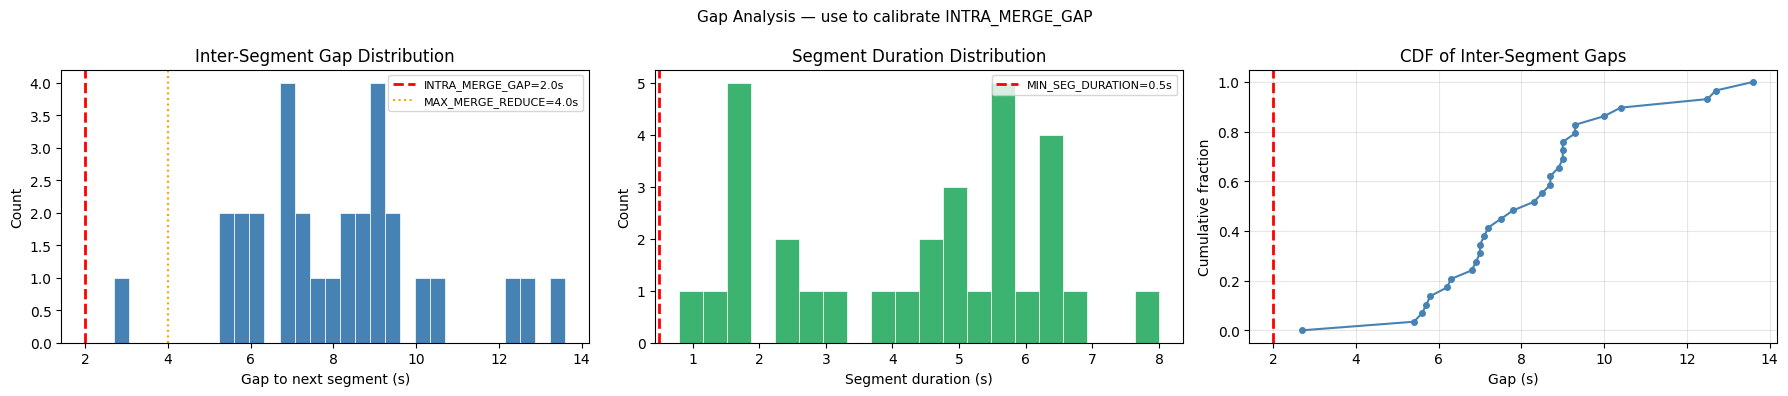

Gap statistics:
  Min gap : 2.70s
  Max gap : 13.60s
  Mean gap: 8.10s
  Median  : 8.05s

Interpretation:
  ⚠ Gaps as small as 2.70s detected.
    May indicate split responses remaining. Consider raising INTRA_MERGE_GAP.


In [9]:
def compute_inter_gaps(segs):
    """Gaps between end of segment[i] and start of segment[i+1]."""
    if len(segs) < 2:
        return np.array([])
    s = segs.sort_values('start').reset_index(drop=True)
    return (s['start'].values[1:] - s['end'].values[:-1])


gaps = compute_inter_gaps(vad_filtered)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Gap distribution histogram
ax = axes[0]
ax.hist(gaps, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(INTRA_MERGE_GAP, color='red', lw=2, ls='--', label=f'INTRA_MERGE_GAP={INTRA_MERGE_GAP}s')
ax.axvline(MAX_MERGE_GAP_FOR_REDUCE, color='orange', lw=1.5, ls=':',
           label=f'MAX_MERGE_REDUCE={MAX_MERGE_GAP_FOR_REDUCE}s')
ax.set(xlabel='Gap to next segment (s)', ylabel='Count', title='Inter-Segment Gap Distribution')
ax.legend(fontsize=8)

# Duration distribution histogram
ax2 = axes[1]
ax2.hist(vad_filtered['duration'], bins=20, color='mediumseagreen', edgecolor='white', linewidth=0.5)
ax2.axvline(MIN_SEG_DURATION, color='red', lw=2, ls='--', label=f'MIN_SEG_DURATION={MIN_SEG_DURATION}s')
ax2.set(xlabel='Segment duration (s)', ylabel='Count', title='Segment Duration Distribution')
ax2.legend(fontsize=8)

# Cumulative gap to see bimodality
ax3 = axes[2]
ax3.plot(sorted(gaps), np.linspace(0, 1, len(gaps)), 'o-', color='steelblue', ms=4)
ax3.axvline(INTRA_MERGE_GAP, color='red', lw=2, ls='--')
ax3.set(xlabel='Gap (s)', ylabel='Cumulative fraction', title='CDF of Inter-Segment Gaps')
ax3.grid(True, alpha=0.3)

plt.suptitle('Gap Analysis — use to calibrate INTRA_MERGE_GAP', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_gap_analysis.png', dpi=150)
plt.show()

print(f"Gap statistics:")
print(f"  Min gap : {gaps.min():.2f}s")
print(f"  Max gap : {gaps.max():.2f}s")
print(f"  Mean gap: {gaps.mean():.2f}s")
print(f"  Median  : {np.median(gaps):.2f}s")
print()
print("Interpretation:")
if gaps.min() > 3.0:
    print(f"  ✓ Smallest gap is {gaps.min():.2f}s — all detected segments are from different pairs.")
    print(f"    No within-response splits remain. INTRA_MERGE_GAP is sufficient.")
else:
    print(f"  ⚠ Gaps as small as {gaps.min():.2f}s detected.")
    print(f"    May indicate split responses remaining. Consider raising INTRA_MERGE_GAP.")

---
## Section 7 — Smart Reduce to N Responses

If we have more segments than expected (e.g., 31 instead of 30), we need to reduce by merging the two closest adjacent segments. These are always a split response — since inter-pair gaps are ~6–8 s, any gap < `MAX_MERGE_GAP_FOR_REDUCE` is intra-response.

If we have **fewer** segments than expected, some responses were truly absent (participant skipped) — those become `MISSING` slots.

In [10]:
def smart_reduce(segs, target_n, max_merge_gap=MAX_MERGE_GAP_FOR_REDUCE):
    """
    Reduce segments to exactly target_n by iteratively merging the pair
    with the smallest inter-segment gap.

    Only merges if the smallest gap ≤ max_merge_gap (safety valve against
    accidentally merging across pair boundaries).

    Returns reduced DataFrame + a log of merge operations.
    """
    df  = segs.sort_values('start').reset_index(drop=True).copy()
    log = []

    while len(df) > target_n:
        # Compute all inter-segment gaps
        gap_values = df['start'].values[1:] - df['end'].values[:-1]
        min_idx    = int(np.argmin(gap_values))
        min_gap    = gap_values[min_idx]

        if min_gap > max_merge_gap:
            log.append(f"STOPPED: smallest gap {min_gap:.2f}s > MAX_MERGE_GAP {max_merge_gap}s. "
                       f"Remaining segments: {len(df)}")
            break

        # Merge segment[min_idx] and segment[min_idx+1]
        a = df.iloc[min_idx]
        b = df.iloc[min_idx + 1]
        new_start = a['start']
        new_end   = b['end']
        log.append(f"Merged seg {min_idx} [{a['start']:.2f}-{a['end']:.2f}s] + "
                   f"seg {min_idx+1} [{b['start']:.2f}-{b['end']:.2f}s] "
                   f"(gap={min_gap:.2f}s) → [{new_start:.2f}-{new_end:.2f}s]")

        rows = df.to_dict('records')
        merged_row = {'start': new_start, 'end': new_end, 'duration': new_end - new_start}
        rows = rows[:min_idx] + [merged_row] + rows[min_idx+2:]
        df   = pd.DataFrame(rows).reset_index(drop=True)

    return df, log


n_before = len(vad_filtered)
print(f"Segments before reduce: {n_before}")
print(f"Target                : {NUM_STIMULI}")
print()

if n_before == NUM_STIMULI:
    responses_df = vad_filtered.copy()
    print(f"✓ Exact match. No reduction needed.")
    reduce_log   = []
elif n_before > NUM_STIMULI:
    responses_df, reduce_log = smart_reduce(vad_filtered, NUM_STIMULI)
    print(f"Merge operations performed:")
    for l in reduce_log:
        print(f"  {l}")
    print(f"\nSegments after reduce : {len(responses_df)}")
else:
    # Fewer than expected — some responses are missing
    responses_df = vad_filtered.copy()
    reduce_log   = []
    print(f"⚠ Only {n_before} segments found (expected {NUM_STIMULI}).")
    print(f"  {NUM_STIMULI - n_before} responses are missing (participant did not respond).")

responses_df = responses_df.reset_index(drop=True)
print(f"\nFinal response pool: {len(responses_df)} segments")
responses_df

Segments before reduce: 31
Target                : 30

Merge operations performed:
  Merged seg 29 [371.00-375.60s] + seg 30 [378.30-379.10s] (gap=2.70s) → [371.00-379.10s]

Segments after reduce : 30

Final response pool: 30 segments


,start,end,duration
0,2.9,4.2,1.3
1,10.0,11.7,1.7
2,17.4,19.0,1.6
3,25.2,27.0,1.8
4,34.5,36.3,1.8
5,43.5,47.4,3.9
6,53.7,59.9,6.2
7,65.3,67.6,2.3
8,76.1,78.4,2.3
9,87.7,90.8,3.1


---
## Section 8 — Sequential Mapping

Assign each detected segment to its corresponding stimulus in **temporal order**. No stimulus detection required — the recording always follows the fixed sequence.

If we have fewer segments than expected, we use a **gap-based missing slot detection**:
- Compute the expected average inter-pair interval: `total_duration / NUM_STIMULI`
- Any gap between consecutive detected responses larger than `1.8 × avg_interval` indicates a skipped stimulus slot
- Insert a MISSING placeholder in that slot and shift the mapping accordingly

In [11]:
def sequential_map_with_gap_detection(
        responses_df,
        stimulus_sentences,
        total_duration,
        skip_gap_ratio=1.8):
    """
    Map detected response segments to stimulus sentences in order.

    If the number of segments equals NUM_STIMULI: direct 1:1 mapping.

    If fewer segments: insert MISSING placeholders where large inter-response
    gaps indicate a participant skipped a stimulus.

    Parameters
    ----------
    skip_gap_ratio : float
        If gap between two responses > skip_gap_ratio × avg_interval,
        a MISSING slot is inserted before the second response.

    Returns
    -------
    DataFrame with 30 rows (one per stimulus), columns:
        stimulus_id, stimulus_text,
        response_start, response_end, response_duration, status
    """
    n_expected = len(stimulus_sentences)
    n_found    = len(responses_df)
    segs       = responses_df.sort_values('start').reset_index(drop=True)

    # ── Case 1: exact match ─────────────────────────────────────────────────
    if n_found == n_expected:
        records = []
        for i, (_, row) in enumerate(segs.iterrows()):
            records.append({
                'stimulus_id'      : i + 1,
                'stimulus_text'    : stimulus_sentences[i],
                'response_start'   : round(row['start'], 4),
                'response_end'     : round(row['end'], 4),
                'response_duration': round(row['duration'], 4),
                'status'           : 'OK'
            })
        return pd.DataFrame(records)

    # ── Case 2: fewer than expected — insert MISSING with gap heuristic ─────
    avg_interval = total_duration / n_expected
    skip_thresh  = skip_gap_ratio * avg_interval

    print(f"Avg interval per pair   : {avg_interval:.2f}s")
    print(f"Skip detection threshold: {skip_thresh:.2f}s (ratio={skip_gap_ratio})")

    # Build ordered list of events: ('response', row) or ('missing',)
    events = []
    prev_end = 0.0

    for _, row in segs.iterrows():
        gap = row['start'] - prev_end
        # How many full skip-gap intervals fit in this gap?
        n_skips = max(0, round(gap / avg_interval) - 1)
        for _ in range(n_skips):
            events.append(('missing', None))
        events.append(('response', row))
        prev_end = row['end']

    # Fill remaining missing slots at end
    while len(events) < n_expected:
        events.append(('missing', None))

    # Trim extras if gap heuristic over-inserted
    # (rare edge case: keep first n_expected events)
    events = events[:n_expected]

    records = []
    for i, (etype, row) in enumerate(events):
        if etype == 'response':
            records.append({
                'stimulus_id'      : i + 1,
                'stimulus_text'    : stimulus_sentences[i],
                'response_start'   : round(row['start'], 4),
                'response_end'     : round(row['end'], 4),
                'response_duration': round(row['duration'], 4),
                'status'           : 'OK'
            })
        else:
            records.append({
                'stimulus_id'      : i + 1,
                'stimulus_text'    : stimulus_sentences[i],
                'response_start'   : None,
                'response_end'     : None,
                'response_duration': None,
                'status'           : 'MISSING'
            })

    return pd.DataFrame(records)


results_df = sequential_map_with_gap_detection(
    responses_df, STIMULUS_SENTENCES, DURATION
)

ok_count   = (results_df['status'] == 'OK').sum()
miss_count = (results_df['status'] == 'MISSING').sum()
print(f"\nMapping complete: {ok_count}/{NUM_STIMULI} responses found, {miss_count} missing")
results_df


Mapping complete: 30/30 responses found, 0 missing


,stimulus_id,stimulus_text,response_start,response_end,response_duration,status
0,1,Quiero cortarme el pelo,2.9,4.2,1.3,OK
1,2,El libro está en la mesa,10.0,11.7,1.7,OK
2,3,El carro lo tiene Pedro,17.4,19.0,1.6,OK
3,4,El se ducha cada mañana,25.2,27.0,1.8,OK
4,5,¿Qué dice usted que va a hacer hoy?,34.5,36.3,1.8,OK
5,6,Dudo que sepa manejar muy bien,43.5,47.4,3.9,OK
6,7,Las calles de esta ciudad son muy anchas,53.7,59.9,6.2,OK
7,8,Puede que llueva mañana todo el día,65.3,67.6,2.3,OK
8,9,Las casas son muy bonitas pero caras,76.1,78.4,2.3,OK
9,10,Me gustan las películas que acaban bien,87.7,90.8,3.1,OK


---
## Section 9 — Validation

Sanity checks on detected responses. Note: we no longer validate against stimulus boundaries (there are none). We check:
- Duration plausibility (≥ MIN_SEG_DURATION)
- No temporal overlap with adjacent responses
- Response duration within expected range for the sentence word count

In [12]:
def validate_responses(results_df, min_dur=MIN_SEG_DURATION):
    """
    Validate each detected response:
    1. Duration ≥ min_dur
    2. No overlap with adjacent response
    3. Duration plausibility vs. word count of stimulus sentence
       (rough: ~0.25s per word for non-native Spanish at slow pace)
    """
    WORDS_PER_SEC = 1.5   # slow non-native speech rate
    df = results_df.copy()
    flags = []

    for i, row in df.iterrows():
        if row['status'] == 'MISSING':
            flags.append('MISSING')
            continue

        issues = []

        # Duration check
        if row['response_duration'] < min_dur:
            issues.append(f'TOO_SHORT({row["response_duration"]:.2f}s)')

        # Overlap with next response
        if i + 1 < len(df) and df.iloc[i+1]['status'] == 'OK':
            if row['response_end'] > df.iloc[i+1]['response_start']:
                issues.append('OVERLAP_NEXT')

        # Word count plausibility
        n_words    = len(row['stimulus_text'].split())
        min_expect = n_words / (WORDS_PER_SEC * 2.5)   # very fast end
        max_expect = n_words / (WORDS_PER_SEC * 0.4)   # very slow end
        if row['response_duration'] < min_expect:
            issues.append(f'SUSPICIOUSLY_SHORT(≥{min_expect:.1f}s expected)')
        elif row['response_duration'] > max_expect:
            issues.append(f'SUSPICIOUSLY_LONG(≤{max_expect:.1f}s expected)')

        flags.append('OK' if not issues else '|'.join(issues))

    df['validation'] = flags
    return df


results_df = validate_responses(results_df)

ok_df   = results_df[results_df['status'] == 'OK']
miss_df = results_df[results_df['status'] == 'MISSING']
warn_df = results_df[(results_df['validation'] != 'OK') &
                     (results_df['status'] == 'OK')]

print("═" * 58)
print("  VALIDATION SUMMARY")
print("═" * 58)
print(f"  Total stimuli     : {len(results_df)}")
print(f"  Responses found   : {len(ok_df)}")
print(f"  Missing           : {len(miss_df)}")
print(f"  Validation flags  : {len(warn_df)}")
if len(ok_df):
    print(f"  Mean duration     : {ok_df['response_duration'].mean():.3f}s")
    print(f"  Std duration      : {ok_df['response_duration'].std():.3f}s")
    print(f"  Min / Max         : {ok_df['response_duration'].min():.3f}s / "
                                 f"{ok_df['response_duration'].max():.3f}s")
print("═" * 58)

if len(miss_df):
    print(f"Missing IDs: {sorted(miss_df['stimulus_id'].tolist())}")
if len(warn_df):
    print("\nValidation warnings:")
    print(warn_df[['stimulus_id', 'stimulus_text', 'response_duration', 'validation']].to_string(index=False))

display(results_df[['stimulus_id','stimulus_text','response_start','response_end',
                     'response_duration','status','validation']])

══════════════════════════════════════════════════════════
  VALIDATION SUMMARY
══════════════════════════════════════════════════════════
  Total stimuli     : 30
  Responses found   : 30
  Missing           : 0
  Validation flags  : 2
  Mean duration     : 4.533s
  Std duration      : 2.035s
  Min / Max         : 1.300s / 8.100s
══════════════════════════════════════════════════════════

Validation warnings:
 stimulus_id                                 stimulus_text  response_duration                         validation
           5           ¿Qué dice usted que va a hacer hoy?                1.8 SUSPICIOUSLY_SHORT(≥2.1s expected)
          26 El ladrón al que atrapó la policía era famoso                1.7 SUSPICIOUSLY_SHORT(≥2.4s expected)


,stimulus_id,stimulus_text,response_start,response_end,response_duration,status,validation
0,1,Quiero cortarme el pelo,2.9,4.2,1.3,OK,OK
1,2,El libro está en la mesa,10.0,11.7,1.7,OK,OK
2,3,El carro lo tiene Pedro,17.4,19.0,1.6,OK,OK
3,4,El se ducha cada mañana,25.2,27.0,1.8,OK,OK
4,5,¿Qué dice usted que va a hacer hoy?,34.5,36.3,1.8,OK,SUSPICIOUSLY_SHORT(≥2.1s expected)
5,6,Dudo que sepa manejar muy bien,43.5,47.4,3.9,OK,OK
6,7,Las calles de esta ciudad son muy anchas,53.7,59.9,6.2,OK,OK
7,8,Puede que llueva mañana todo el día,65.3,67.6,2.3,OK,OK
8,9,Las casas son muy bonitas pero caras,76.1,78.4,2.3,OK,OK
9,10,Me gustan las películas que acaban bien,87.7,90.8,3.1,OK,OK


---
## Section 10 — Visualization

Saved: eit_output_v3/038012_2A_preprocessed/02_timeline.png


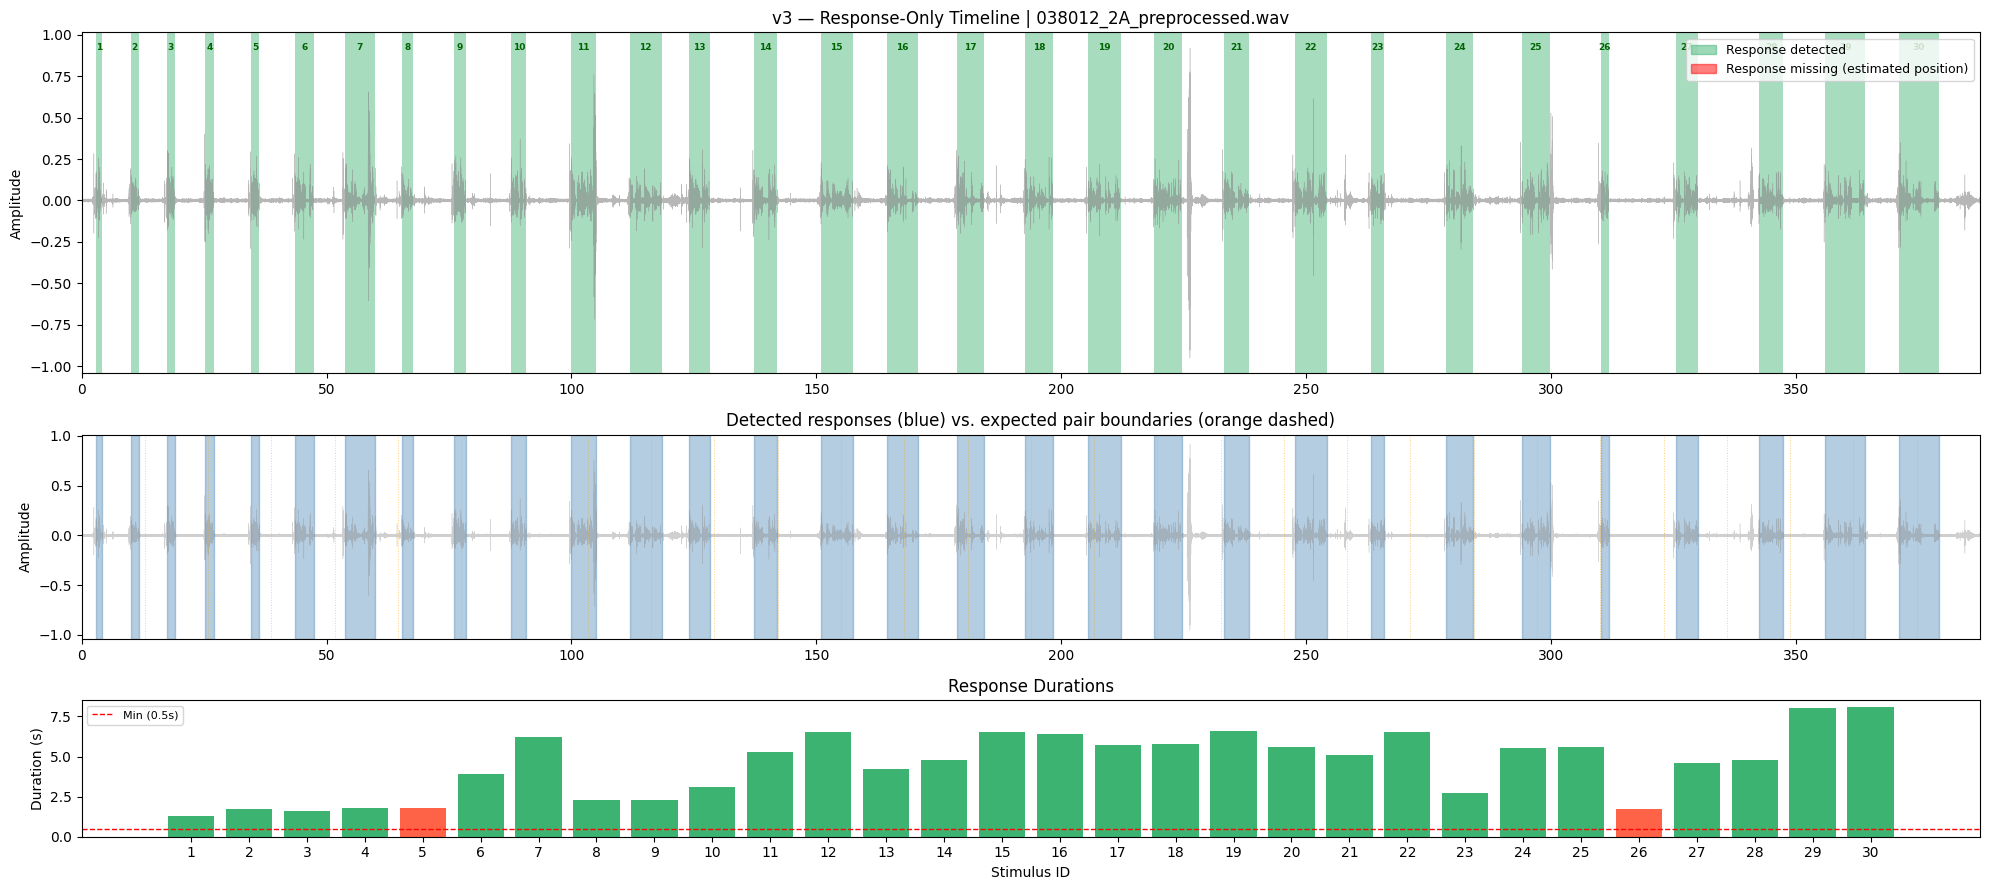

In [13]:
def plot_full_timeline(audio, sr, duration, results_df, output_path=None):
    fig, axes = plt.subplots(3, 1, figsize=(20, 9),
                              gridspec_kw={'height_ratios': [2.5, 1.5, 1]})
    t = np.linspace(0, duration, len(audio))

    # ── Top: waveform + response regions ──────────────────────────────────
    ax = axes[0]
    ax.plot(t, audio, color='#888', lw=0.3, alpha=0.6)

    colors = {'OK': 'mediumseagreen', 'MISSING': 'lightgray'}
    for _, row in results_df.iterrows():
        sid = int(row['stimulus_id'])
        if row['status'] == 'OK':
            # Response span
            ax.axvspan(row['response_start'], row['response_end'],
                       alpha=0.45, color='mediumseagreen', linewidth=0)
            # ID label above span
            mid = (row['response_start'] + row['response_end']) / 2
            ax.text(mid, 0.97, str(sid), transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=6.5, color='darkgreen', fontweight='bold')
        else:
            # Estimate where the missing response should have been
            est_t = sid / NUM_STIMULI * duration
            ax.axvline(est_t, color='red', lw=1.2, ls='--', alpha=0.6)
            ax.text(est_t, 0.97, str(sid), transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=6.5, color='red')

    patches = [
        mpatches.Patch(color='mediumseagreen', alpha=0.5, label='Response detected'),
        mpatches.Patch(color='red',            alpha=0.5, label='Response missing (estimated position)'),
    ]
    ax.legend(handles=patches, loc='upper right', fontsize=9)
    ax.set(ylabel='Amplitude', xlim=(0, duration),
           title=f'v3 — Response-Only Timeline | {Path(AUDIO_PATH).name}')

    # ── Middle: detected segments vs expected spacing ─────────────────────
    ax2 = axes[1]
    ax2.plot(t, audio, color='#888', lw=0.3, alpha=0.4)
    for _, row in results_df.iterrows():
        if row['status'] == 'OK':
            ax2.axvspan(row['response_start'], row['response_end'],
                        alpha=0.4, color='steelblue')
    # Expected pair boundaries (for reference)
    for i in range(1, NUM_STIMULI):
        ax2.axvline(i / NUM_STIMULI * duration, color='orange',
                    lw=0.7, alpha=0.5, ls=':')
    ax2.set(ylabel='Amplitude', xlim=(0, duration),
            title='Detected responses (blue) vs. expected pair boundaries (orange dashed)')

    # ── Bottom: duration bar chart ─────────────────────────────────────────
    ax3 = axes[2]
    ok = results_df[results_df['status'] == 'OK']
    bar_colors = ['mediumseagreen' if v == 'OK' else 'tomato' for v in ok['validation']]
    ax3.bar(ok['stimulus_id'], ok['response_duration'], color=bar_colors, width=0.8, edgecolor='none')
    ax3.axhline(MIN_SEG_DURATION, color='red', ls='--', lw=1, label=f'Min ({MIN_SEG_DURATION}s)')
    ax3.set(xlabel='Stimulus ID', ylabel='Duration (s)', title='Response Durations')
    ax3.set_xticks(range(1, NUM_STIMULI + 1))
    ax3.legend(fontsize=8)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {output_path}")
    plt.show()


plot_full_timeline(audio, SR, DURATION, results_df,
                   output_path=OUTPUT_DIR / '02_timeline.png')

Saved: eit_output_v3/038012_2A_preprocessed/03_per_response_detail.png


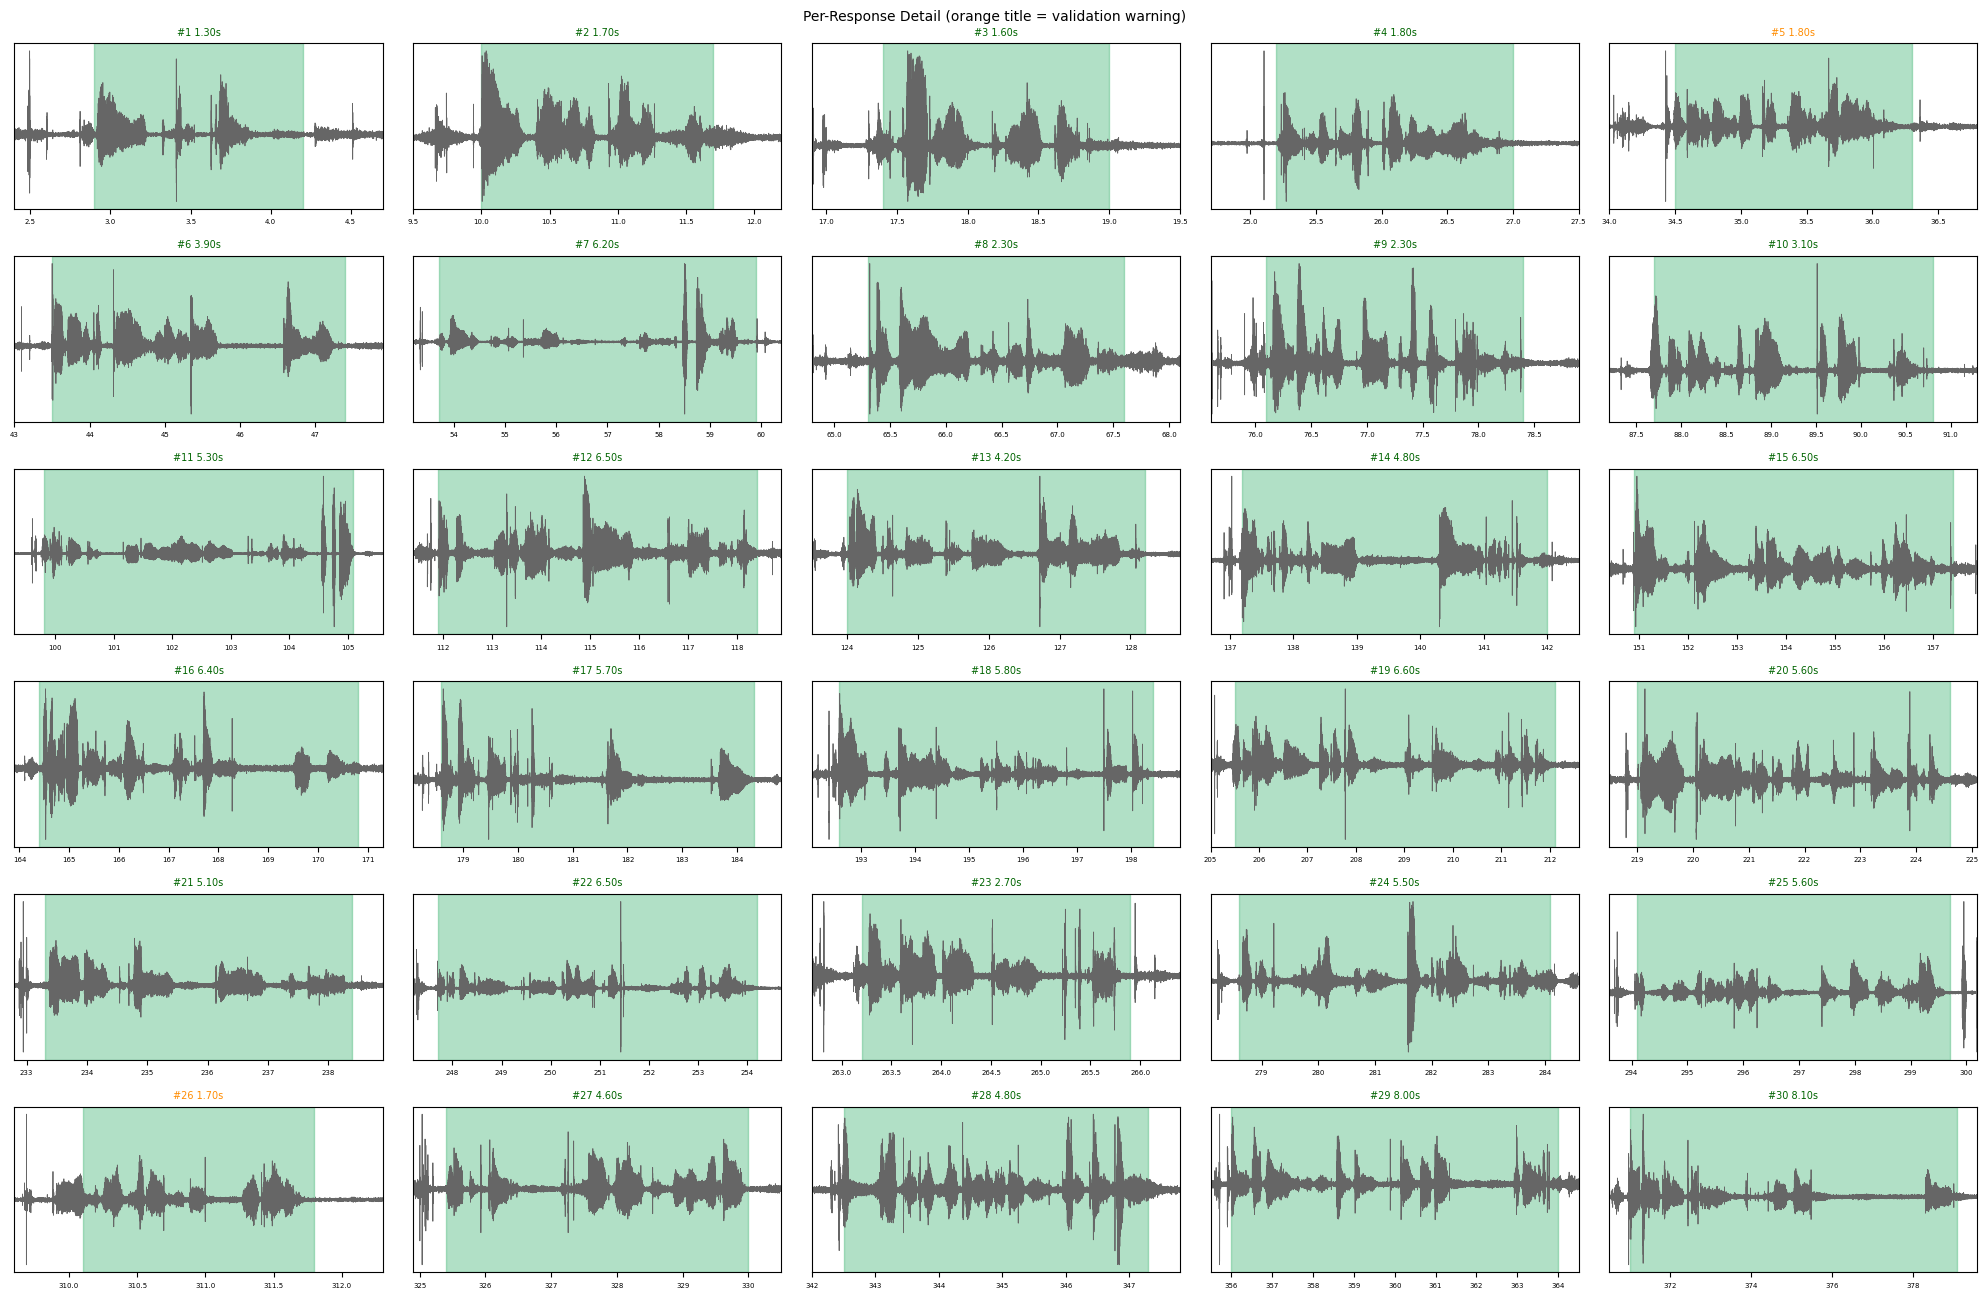

In [14]:
def plot_per_response_detail(audio, sr, results_df, n_cols=5, output_path=None):
    """30-panel zoom for manual QA of each response."""
    n      = len(results_df)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*2.2))
    axes = axes.flatten()

    for idx, row in results_df.iterrows():
        ax  = axes[idx]
        sid = int(row['stimulus_id'])

        if row['status'] == 'OK':
            t0   = max(0.0, row['response_start'] - 0.5)
            t1   = min(DURATION, row['response_end'] + 0.5)
            clip = audio[int(t0*sr): int(t1*sr)]
            tl   = np.linspace(t0, t1, len(clip))
            ax.plot(tl, clip, color='#666', lw=0.6)
            ax.axvspan(row['response_start'], row['response_end'],
                       alpha=0.4, color='mediumseagreen')
            title = f"#{sid} {row['response_duration']:.2f}s"
            color = 'darkgreen' if row['validation'] == 'OK' else 'darkorange'
        else:
            # Show ~5 s around estimated position
            est = sid / NUM_STIMULI * DURATION
            t0  = max(0.0, est - 2.5)
            t1  = min(DURATION, est + 2.5)
            clip = audio[int(t0*sr): int(t1*sr)]
            tl   = np.linspace(t0, t1, len(clip))
            ax.plot(tl, clip, color='#aaa', lw=0.6)
            title = f"#{sid} MISSING"
            color = 'red'

        ax.set_title(title, fontsize=7, color=color)
        ax.set_xlim(t0, t1)
        ax.set_yticks([])
        ax.tick_params(labelsize=5)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Per-Response Detail (orange title = validation warning)', fontsize=10)
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=130, bbox_inches='tight')
        print(f"Saved: {output_path}")
    plt.show()


plot_per_response_detail(audio, SR, results_df,
                          output_path=OUTPUT_DIR / '03_per_response_detail.png')

---
## Section 11 — Export

In [15]:
def export_responses(audio, sr, results_df, output_dir, padding_s=0.05):
    """Write one WAV per response slot. Missing slots get silent placeholders."""
    resp_dir = output_dir / 'responses'
    resp_dir.mkdir(parents=True, exist_ok=True)
    pad = int(padding_s * sr)
    df  = results_df.copy()
    df['response_file'] = None

    for _, row in tqdm(df.iterrows(), total=len(df), desc='Exporting'):
        sid  = int(row['stimulus_id'])
        path = resp_dir / f'response_{sid:02d}.wav'

        if row['status'] == 'OK':
            s0 = max(0, int(row['response_start'] * sr) - pad)
            s1 = min(len(audio), int(row['response_end'] * sr) + pad)
            sf.write(str(path), audio[s0:s1], sr, subtype='PCM_16')
            df.at[_, 'response_file'] = str(path)
        else:
            sf.write(str(path), np.zeros(int(0.1*sr), np.float32), sr, subtype='PCM_16')
            df.at[_, 'response_file'] = f'{path} [MISSING]'

    return df


results_df = export_responses(audio, SR, results_df, OUTPUT_DIR)

csv_path = OUTPUT_DIR / 'segments.csv'
results_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"\nExported: {OUTPUT_DIR / 'responses'}")
print(f"CSV     : {csv_path}")
display(results_df)

Exporting: 100%|██████████| 30/30 [00:00<00:00, 738.64it/s]


Exported: eit_output_v3/038012_2A_preprocessed/responses
CSV     : eit_output_v3/038012_2A_preprocessed/segments.csv


,stimulus_id,stimulus_text,response_start,response_end,response_duration,status,validation,response_file
0,1,Quiero cortarme el pelo,2.9,4.2,1.3,OK,OK,eit_output_v3/038012_2A_preprocessed/responses...
1,2,El libro está en la mesa,10.0,11.7,1.7,OK,OK,eit_output_v3/038012_2A_preprocessed/responses...
2,3,El carro lo tiene Pedro,17.4,19.0,1.6,OK,OK,eit_output_v3/038012_2A_preprocessed/responses...
3,4,El se ducha cada mañana,25.2,27.0,1.8,OK,OK,eit_output_v3/038012_2A_preprocessed/responses...
4,5,¿Qué dice usted que va a hacer hoy?,34.5,36.3,1.8,OK,SUSPICIOUSLY_SHORT(≥2.1s expected),eit_output_v3/038012_2A_preprocessed/responses...
5,6,Dudo que sepa manejar muy bien,43.5,47.4,3.9,OK,OK,eit_output_v3/038012_2A_preprocessed/responses...
6,7,Las calles de esta ciudad son muy anchas,53.7,59.9,6.2,OK,OK,eit_output_v3/038012_2A_preprocessed/responses...
7,8,Puede que llueva mañana todo el día,65.3,67.6,2.3,OK,OK,eit_output_v3/038012_2A_preprocessed/responses...
8,9,Las casas son muy bonitas pero caras,76.1,78.4,2.3,OK,OK,eit_output_v3/038012_2A_preprocessed/responses...
9,10,Me gustan las películas que acaban bien,87.7,90.8,3.1,OK,OK,eit_output_v3/038012_2A_preprocessed/responses...


---
## Section 12 — INTRA_MERGE_GAP Sweep

Run multiple merge gaps and report segments found at each value. Use this to pick the right `INTRA_MERGE_GAP` for a new recording without re-running the full pipeline.

In [16]:
print("INTRA_MERGE_GAP sweep — segments surviving after merge + duration filter")
print(f"{'Gap (s)':>10} {'Raw segs':>10} {'After filter':>14} {'Note':>30}")
print("-" * 68)

for gap in [0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0, 4.0]:
    m = merge_by_gap(vad_raw, gap)
    f = m[m['duration'] >= MIN_SEG_DURATION]
    n = len(f)
    diff = n - NUM_STIMULI
    note = "✓ exact" if diff==0 else (f"↑ {diff} over" if diff>0 else f"↓ {abs(diff)} under")
    marker = " ◀" if gap == INTRA_MERGE_GAP else ""
    print(f"{gap:>10.1f} {len(m):>10} {n:>14} {note:>30}{marker}")

print("-" * 68)
print("Set INTRA_MERGE_GAP to the value that gives closest to NUM_STIMULI segments.")
print("Then re-run Sections 5 onward.")

INTRA_MERGE_GAP sweep — segments surviving after merge + duration filter
   Gap (s)   Raw segs   After filter                           Note
--------------------------------------------------------------------
       0.3         58             55                      ↑ 25 over
       0.5         47             46                      ↑ 16 over
       0.8         42             42                      ↑ 12 over
       1.0         34             34                       ↑ 4 over
       1.2         34             34                       ↑ 4 over
       1.5         31             31                       ↑ 1 over
       2.0         31             31                       ↑ 1 over ◀
       2.5         31             31                       ↑ 1 over
       3.0         30             30                        ✓ exact
       4.0         30             30                        ✓ exact
--------------------------------------------------------------------
Set INTRA_MERGE_GAP to the value that g

---
## Section 13 — Diagnostic Report

In [17]:
ok_df   = results_df[results_df['status'] == 'OK']
miss_df = results_df[results_df['status'] == 'MISSING']

print("═" * 60)
print("  EIT SEGMENTATION v3 — DIAGNOSTIC REPORT")
print("═" * 60)
print(f"  File              : {Path(AUDIO_PATH).name}")
print(f"  Duration          : {DURATION:.2f}s ({DURATION/60:.2f} min)")
print(f"  Expected responses: {NUM_STIMULI}")
print(f"  Responses found   : {len(ok_df)}")
print(f"  Missing           : {len(miss_df)}")
if len(miss_df):
    print(f"  Missing IDs       : {sorted(miss_df['stimulus_id'].tolist())}")
if len(ok_df):
    print(f"  Mean resp. dur.   : {ok_df['response_duration'].mean():.3f}s")
    print(f"  Std resp. dur.    : {ok_df['response_duration'].std():.3f}s")
    print(f"  Min / Max         : {ok_df['response_duration'].min():.3f}s / "
                                f"{ok_df['response_duration'].max():.3f}s")
print("─" * 60)
print("  PARAMETERS")
print("─" * 60)
print(f"  VAD_THRESHOLD        = {VAD_THRESHOLD}")
print(f"  VAD_MIN_SPEECH_MS    = {VAD_MIN_SPEECH_MS}")
print(f"  VAD_MIN_SILENCE_MS   = {VAD_MIN_SILENCE_MS}")
print(f"  INTRA_MERGE_GAP      = {INTRA_MERGE_GAP}s")
print(f"  MIN_SEG_DURATION     = {MIN_SEG_DURATION}s")
print(f"  MAX_MERGE_GAP_REDUCE = {MAX_MERGE_GAP_FOR_REDUCE}s")
print("═" * 60)
print(f"\nOutput: {OUTPUT_DIR}")

════════════════════════════════════════════════════════════
  EIT SEGMENTATION v3 — DIAGNOSTIC REPORT
════════════════════════════════════════════════════════════
  File              : 038012_2A_preprocessed.wav
  Duration          : 387.55s (6.46 min)
  Expected responses: 30
  Responses found   : 30
  Missing           : 0
  Mean resp. dur.   : 4.533s
  Std resp. dur.    : 2.035s
  Min / Max         : 1.300s / 8.100s
────────────────────────────────────────────────────────────
  PARAMETERS
────────────────────────────────────────────────────────────
  VAD_THRESHOLD        = 0.4
  VAD_MIN_SPEECH_MS    = 100
  VAD_MIN_SILENCE_MS   = 100
  INTRA_MERGE_GAP      = 2.0s
  MIN_SEG_DURATION     = 0.5s
  MAX_MERGE_GAP_REDUCE = 4.0s
════════════════════════════════════════════════════════════

Output: eit_output_v3/038012_2A_preprocessed


---
## Appendix — Quick Recalibration Cell

Adjust parameters and re-run from the merge step without reloading audio or rerunning VAD.

In [ ]:
# ── Adjust here and re-run this cell only ──────────────────────────────────
INTRA_MERGE_GAP         = 2.0   # seconds — main knob
MIN_SEG_DURATION        = 0.5   # seconds
MAX_MERGE_GAP_FOR_REDUCE = 4.0  # safety cap

# ── Reprocess ────────────────────────────────────────────────────────────
_merged   = merge_by_gap(vad_raw, INTRA_MERGE_GAP)
_filtered = _merged[_merged['duration'] >= MIN_SEG_DURATION].reset_index(drop=True)
print(f"After merge+filter: {len(_filtered)} segments")

_gaps = compute_inter_gaps(_filtered)
print(f"Gap range: {_gaps.min():.2f}s – {_gaps.max():.2f}s  (mean {_gaps.mean():.2f}s)")

if len(_filtered) > NUM_STIMULI:
    _reduced, _log = smart_reduce(_filtered, NUM_STIMULI, MAX_MERGE_GAP_FOR_REDUCE)
    print(f"After reduce: {len(_reduced)} segments")
    for l in _log: print(f"  {l}")
else:
    _reduced = _filtered

_results = sequential_map_with_gap_detection(_reduced, STIMULUS_SENTENCES, DURATION)
_results  = validate_responses(_results)
_ok       = (_results['status'] == 'OK').sum()
print(f"\nResponses: {_ok}/{NUM_STIMULI}")
print(f"Missing IDs: {sorted(_results[_results['status']=='MISSING']['stimulus_id'].tolist())}")
display(_results[['stimulus_id','stimulus_text','response_start','response_end','response_duration','status','validation']])